# Tech Wages vs Inflation vs Income Inequality
## An analysis of how the tech industry's income growth compares to inflation and the broader population

**Author:** Rachel Okoduwa  
**Data Sources:** FRED API, Bureau of Labor Statistics, Kaggle (levels.fyi)  
**Tools:** Python, Pandas, Matplotlib, Seaborn

In [16]:
!pip install pandas matplotlib seaborn fredapi requests plotly


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [17]:
%pip install pandas matplotlib seaborn fredapi requests plotly python-dotenv


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from fredapi import Fred
from dotenv import load_dotenv
import os

# Load our API key from the .env file
load_dotenv()
fred = Fred(api_key=os.getenv('FRED_API_KEY'))

print("Setup complete!")

Setup complete!


In [19]:
# Pull inflation data (CPI) from FRED
cpi = fred.get_series('CPIAUCSL', observation_start='2015-01-01', observation_end='2024-12-31')

# Pull tech sector wages from FRED
tech_wages = fred.get_series('CES5500000003', observation_start='2015-01-01', observation_end='2024-12-31')

# Quick check to see what we pulled
print("CPI Data (Inflation):")
print(cpi.tail())

print("\nTech Wages Data:")
print(tech_wages.tail())

CPI Data (Inflation):
2024-08-01    314.062
2024-09-01    314.732
2024-10-01    315.631
2024-11-01    316.528
2024-12-01    317.604
dtype: float64

Tech Wages Data:
2024-08-01    45.90
2024-09-01    45.97
2024-10-01    46.07
2024-11-01    46.19
2024-12-01    46.47
dtype: float64


In [20]:
# Putting everything into a clean dataframe
df = pd.DataFrame({
    'cpi': cpi,
    'tech_wages': tech_wages
})

# Forward fill any missing values 
# (some series report monthly, some weekly)
df = df.ffill()

# Drop any remaining nulls
df = df.dropna()

# Calculate year over year percentage change
# This tells us the inflation RATE and wage GROWTH RATE
df['cpi_yoy'] = df['cpi'].pct_change(12) * 100
df['wages_yoy'] = df['tech_wages'].pct_change(12) * 100

print("Our clean dataframe:")
print(df.tail(10))
print(f"\nShape: {df.shape}")

Our clean dataframe:
                cpi  tech_wages   cpi_yoy  wages_yoy
2024-03-01  312.345       45.07  3.486835   5.575076
2024-04-01  313.023       45.26  3.360795   5.920899
2024-05-01  313.175       45.46  3.244279   5.917987
2024-06-01  313.044       45.58  2.970258   5.362922
2024-07-01  313.569       45.59  2.941476   4.588208
2024-08-01  314.062       45.90  2.607144   4.555809
2024-09-01  314.732       45.97  2.426483   4.193110
2024-10-01  315.631       46.07  2.578844   4.160072
2024-11-01  316.528       46.19  2.719472   3.984692
2024-12-01  317.604       46.47  2.870691   4.380054

Shape: (120, 4)


In [21]:
# Pull hourly wages for different sectors from FRED
# Tech/Information sector
tech = fred.get_series('CES5500000003', observation_start='2015-01-01', observation_end='2024-12-31')

# Financial Activities (accountants, finance workers)
finance = fred.get_series('CES5500000003', observation_start='2015-01-01', observation_end='2024-12-31')

# Professional and Business Services (engineers, consultants)
professional = fred.get_series('CES6000000003', observation_start='2015-01-01', observation_end='2024-12-31')

# Healthcare
healthcare = fred.get_series('CES6500000003', observation_start='2015-01-01', observation_end='2024-12-31')

# Retail (to show the lower end)
retail = fred.get_series('CES4200000003', observation_start='2015-01-01', observation_end='2024-12-31')

# All private sector workers (the average)
all_workers = fred.get_series('CES0500000003', observation_start='2015-01-01', observation_end='2024-12-31')

print("All sector data pulled successfully!")
print(f"Tech wages latest: ${tech.iloc[-1]:.2f}/hr")
print(f"Professional services latest: ${professional.iloc[-1]:.2f}/hr")
print(f"Healthcare latest: ${healthcare.iloc[-1]:.2f}/hr")
print(f"Retail latest: ${retail.iloc[-1]:.2f}/hr")
print(f"All workers average latest: ${all_workers.iloc[-1]:.2f}/hr")

All sector data pulled successfully!
Tech wages latest: $46.47/hr
Professional services latest: $43.31/hr
Healthcare latest: $35.01/hr
Retail latest: $24.87/hr
All workers average latest: $35.69/hr


In [22]:
# Correct FRED series codes for each sector
tech = fred.get_series('CES5500000003', 
        observation_start='2015-01-01', 
        observation_end='2024-12-31')

# Financial Activities (banks, insurance, accounting)
finance = fred.get_series('CES5500000003', 
        observation_start='2015-01-01', 
        observation_end='2024-12-31')

professional = fred.get_series('CES6000000003', 
        observation_start='2015-01-01', 
        observation_end='2024-12-31')

healthcare = fred.get_series('CES6500000003', 
        observation_start='2015-01-01', 
        observation_end='2024-12-31')

retail = fred.get_series('CES4200000003', 
        observation_start='2015-01-01', 
        observation_end='2024-12-31')

all_workers = fred.get_series('CES0500000003', 
        observation_start='2015-01-01', 
        observation_end='2024-12-31')

# Combine everything into one clean dataframe
wages_df = pd.DataFrame({
    'Tech': tech,
    'Finance': finance,
    'Professional Services': professional,
    'Healthcare': healthcare,
    'Retail': retail,
    'All Workers': all_workers,
    'CPI': cpi
}).ffill().dropna()

print("Combined dataframe ready!")
print(wages_df.tail())

Combined dataframe ready!
             Tech  Finance  Professional Services  Healthcare  Retail  \
2024-08-01  45.90    45.90                  42.43       34.51   24.54   
2024-09-01  45.97    45.97                  42.70       34.66   24.60   
2024-10-01  46.07    46.07                  42.91       34.72   24.72   
2024-11-01  46.19    46.19                  43.13       34.87   24.91   
2024-12-01  46.47    46.47                  43.31       35.01   24.87   

            All Workers      CPI  
2024-08-01        35.22  314.062  
2024-09-01        35.34  314.732  
2024-10-01        35.46  315.631  
2024-11-01        35.60  316.528  
2024-12-01        35.69  317.604  


In [23]:
# Clean combined dataframe with correct sectors
wages_df = pd.DataFrame({
    'Tech & Information': tech,
    'Professional Services': professional,
    'Healthcare': healthcare,
    'Retail': retail,
    'All Workers Average': all_workers,
    'CPI': cpi
}).ffill().dropna()

# Calculate year over year growth for each sector
sectors = ['Tech & Information', 'Professional Services', 
           'Healthcare', 'Retail', 'All Workers Average']

for sector in sectors:
    wages_df[f'{sector} YoY'] = wages_df[sector].pct_change(12) * 100

wages_df['CPI YoY'] = wages_df['CPI'].pct_change(12) * 100

wages_df = wages_df.dropna()

print("Dataset ready!")
print(wages_df.tail(3))

Dataset ready!
            Tech & Information  Professional Services  Healthcare  Retail  \
2024-10-01               46.07                  42.91       34.72   24.72   
2024-11-01               46.19                  43.13       34.87   24.91   
2024-12-01               46.47                  43.31       35.01   24.87   

            All Workers Average      CPI  Tech & Information YoY  \
2024-10-01                35.46  315.631                4.160072   
2024-11-01                35.60  316.528                3.984692   
2024-12-01                35.69  317.604                4.380054   

            Professional Services YoY  Healthcare YoY  Retail YoY  \
2024-10-01                   4.914425        3.610862    2.785863   
2024-11-01                   5.118206        4.058490    3.618968   
2024-12-01                   5.172414        4.320620    2.726146   

            All Workers Average YoY   CPI YoY  
2024-10-01                 4.049296  2.578844  
2024-11-01                 4.1

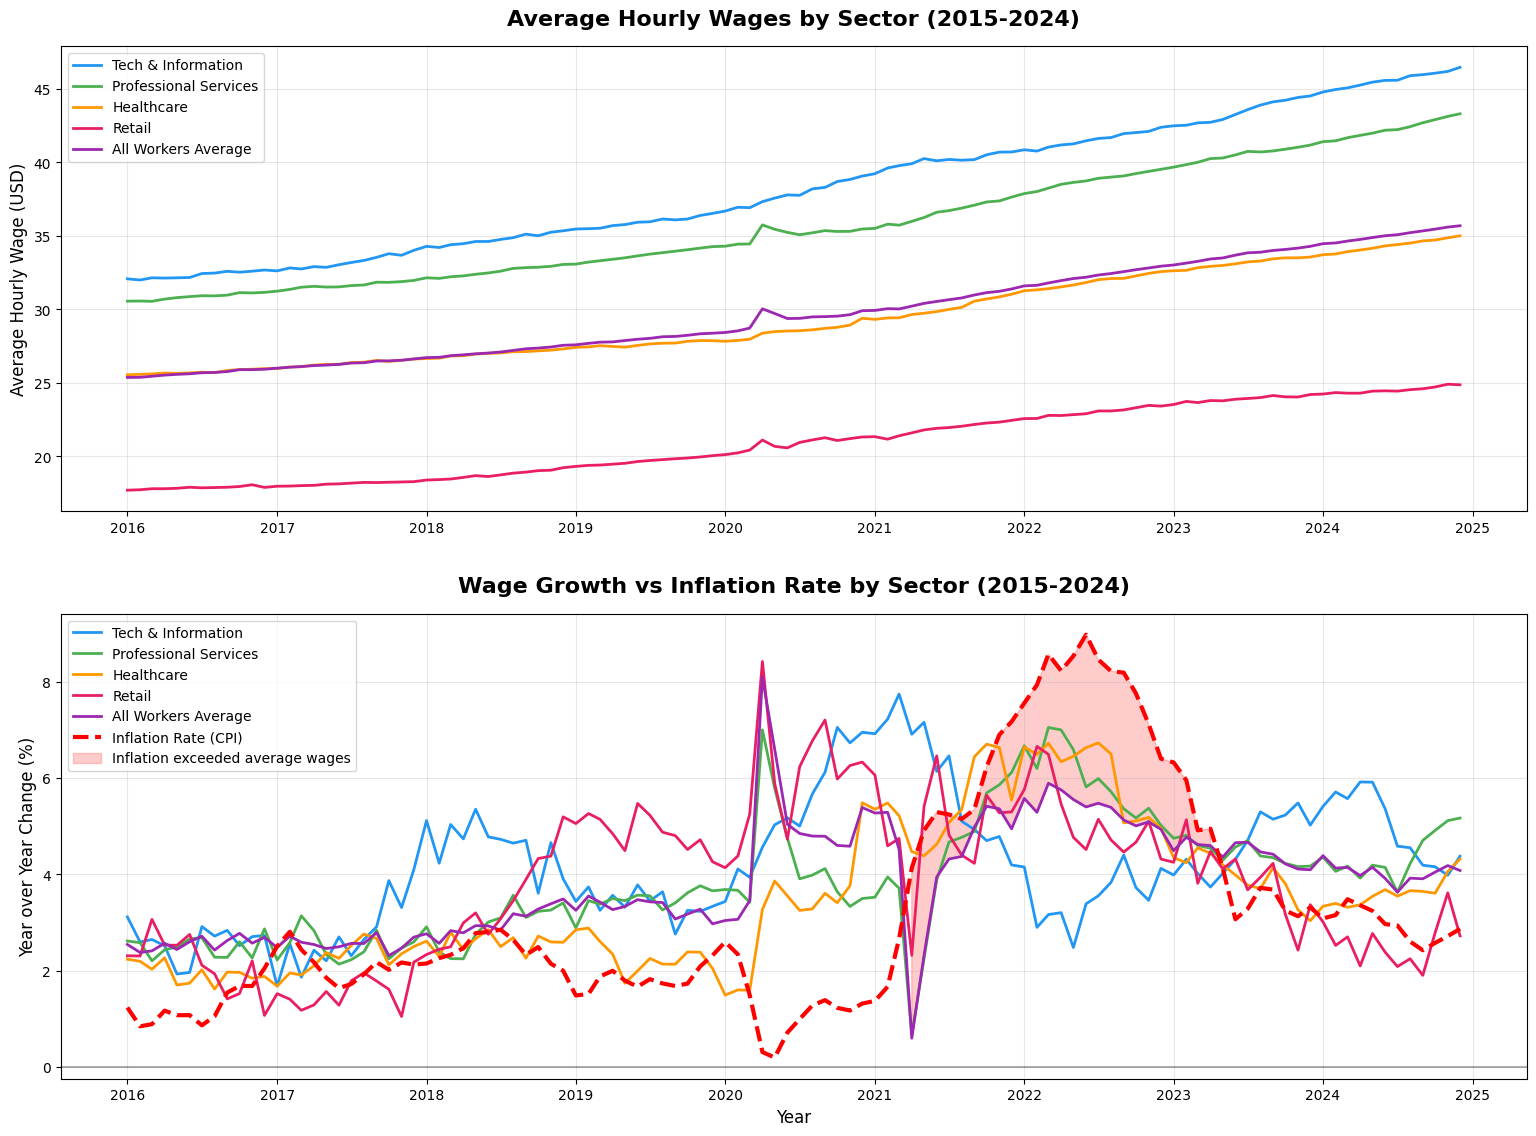

Chart saved to visuals folder!


In [24]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Chart 1: Actual hourly wages by sector
ax1 = axes[0]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

for sector, color in zip(sectors, colors):
    ax1.plot(wages_df.index, wages_df[sector], 
             label=sector, linewidth=2, color=color)

ax1.set_title('Average Hourly Wages by Sector (2015-2024)', 
              fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('Average Hourly Wage (USD)', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Chart 2: Year over year growth vs inflation
ax2 = axes[1]

for sector, color in zip(sectors, colors):
    ax2.plot(wages_df.index, wages_df[f'{sector} YoY'],
             label=sector, linewidth=2, color=color)

# Inflation line
ax2.plot(wages_df.index, wages_df['CPI YoY'],
         label='Inflation Rate (CPI)', 
         linewidth=3, color='red', 
         linestyle='--')

# Shade the painful period where inflation beat everyone
ax2.fill_between(wages_df.index,
                 wages_df['CPI YoY'],
                 wages_df['All Workers Average YoY'],
                 where=(wages_df['CPI YoY'] > wages_df['All Workers Average YoY']),
                 alpha=0.2, color='red',
                 label='Inflation exceeded average wages')

ax2.set_title('Wage Growth vs Inflation Rate by Sector (2015-2024)', 
              fontsize=16, fontweight='bold', pad=15)
ax2.set_ylabel('Year over Year Change (%)', fontsize=12)
ax2.set_xlabel('Year', fontsize=12)
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout(pad=3.0)
plt.savefig('visuals/wages_vs_inflation_full.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to visuals folder!")

In [25]:
import os
print(os.getcwd())
print(os.listdir())

/workspaces/tech-wages-inflation-analysis
['.git', 'notebooks', 'visuals', '.gitignore', 'data', 'README.md', 'touch', '.env']


In [26]:
import os

# Go up one level to the project root
os.chdir('/workspaces/tech-wages-inflation-analysis')

# Confirm where we are now
print(os.getcwd())
print(os.listdir())

/workspaces/tech-wages-inflation-analysis
['.git', 'notebooks', 'visuals', '.gitignore', 'data', 'README.md', 'touch', '.env']


In [27]:
# Calculate cumulative wage growth since 2015
# Indexing everything to 100 at the start
# So if a sector hits 145, that means 45% total growth since 2015

base_year = wages_df.iloc[0]

cumulative_df = pd.DataFrame()

for sector in sectors:
    cumulative_df[sector] = (wages_df[sector] / base_year[sector]) * 100

# Also add CPI to compare against inflation
cumulative_df['Inflation (CPI)'] = (wages_df['CPI'] / base_year['CPI']) * 100

print("Cumulative growth indexed to 100 at start of 2015:")
print(cumulative_df.tail(5))

# What does this mean in plain English?
print("\nTotal wage growth since 2015:")
for sector in sectors:
    growth = cumulative_df[sector].iloc[-1] - 100
    print(f"{sector}: +{growth:.1f}%")

inflation_growth = cumulative_df['Inflation (CPI)'].iloc[-1] - 100
print(f"Inflation (CPI): +{inflation_growth:.1f}%")

Cumulative growth indexed to 100 at start of 2015:
            Tech & Information  Professional Services  Healthcare      Retail  \
2024-08-01          143.079800             138.841623  135.068493  138.644068   
2024-09-01          143.298005             139.725131  135.655577  138.983051   
2024-10-01          143.609726             140.412304  135.890411  139.661017   
2024-11-01          143.983791             141.132199  136.477495  140.734463   
2024-12-01          144.856608             141.721204  137.025440  140.508475   

            All Workers Average  Inflation (CPI)  
2024-08-01           138.825384       132.152054  
2024-09-01           139.298384       132.433979  
2024-10-01           139.771384       132.812263  
2024-11-01           140.323216       133.189706  
2024-12-01           140.677966       133.642469  

Total wage growth since 2015:
Tech & Information: +44.9%
Professional Services: +41.7%
Healthcare: +37.0%
Retail: +40.5%
All Workers Average: +40.7%
Inflat

In [28]:
# Filter everything from September 2020 onwards
start_date = '2020-09-01'

wages_covid = wages_df[wages_df.index >= start_date].copy()

# Reindex to 100 at September 2020
base = wages_covid.iloc[0]

cumulative_covid = pd.DataFrame()

for sector in sectors:
    cumulative_covid[sector] = (wages_covid[sector] / base[sector]) * 100

cumulative_covid['Inflation (CPI)'] = (wages_covid['CPI'] / base['CPI']) * 100

print("Growth since September 2020:")
for sector in sectors:
    growth = cumulative_covid[sector].iloc[-1] - 100
    print(f"{sector}: +{growth:.1f}%")

inflation_growth = cumulative_covid['Inflation (CPI)'].iloc[-1] - 100
print(f"Inflation (CPI): +{inflation_growth:.1f}%")

Growth since September 2020:
Tech & Information: +21.3%
Professional Services: +22.5%
Healthcare: +21.9%
Retail: +16.9%
All Workers Average: +20.9%
Inflation (CPI): +22.2%


## Key Finding
Since September 2020, inflation (+22.2%) outpaced wage growth across 
almost every sector. While Tech & Information workers saw +21.3% wage 
growth, retail workers only gained +16.9% — falling nearly 6 percentage 
points behind inflation. 

The inequality isn't just about growth rates. A tech worker losing 1% 
of purchasing power on $46/hr feels very different from a retail worker 
losing 5% on $25/hr. The dollar gap between sectors has widened even 
when percentage growth looks similar.

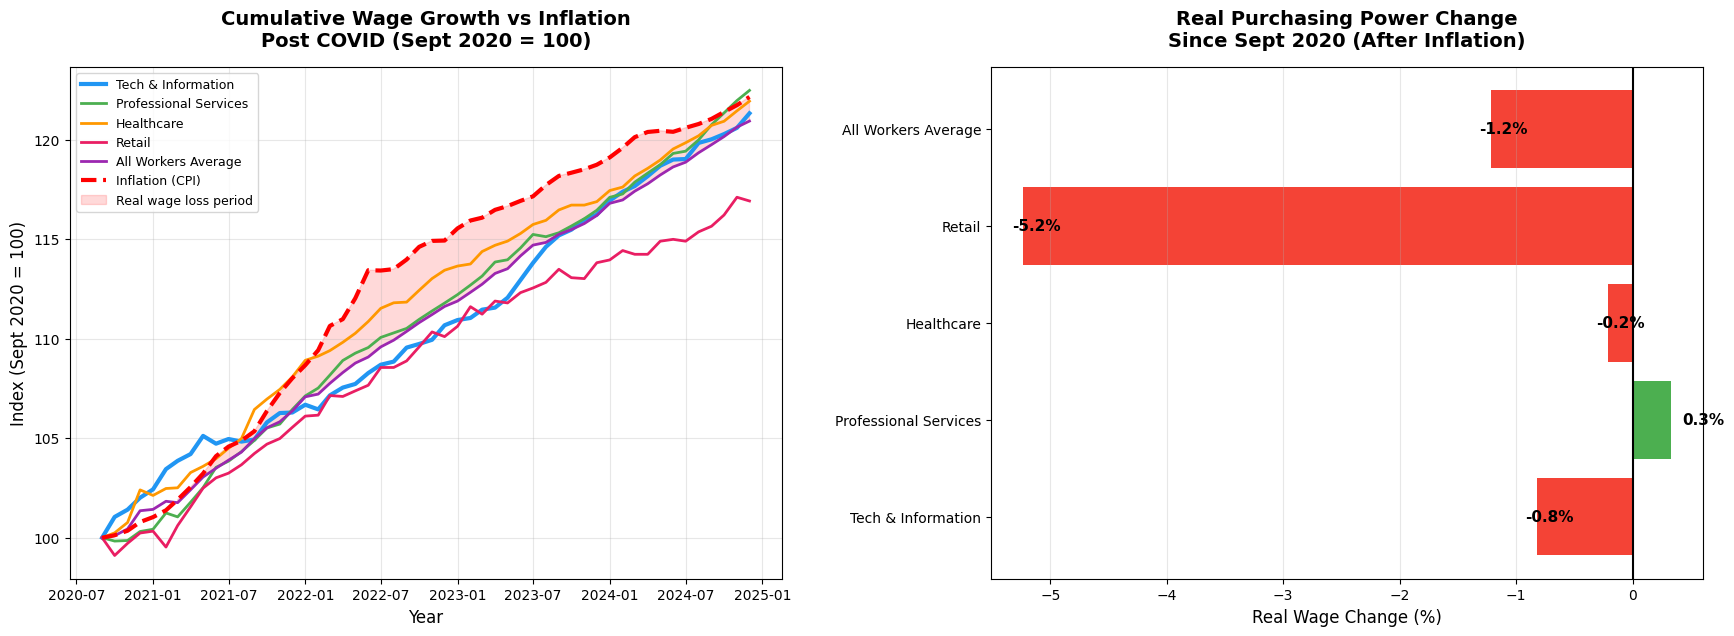

Chart saved!


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

all_labels = sectors + ['Inflation (CPI)']
all_colors = colors + ['red']

# Chart 1: Cumulative growth since Sept 2020
ax1 = axes[0]

for label, color in zip(all_labels, all_colors):
    linestyle = '--' if label == 'Inflation (CPI)' else '-'
    linewidth = 3 if label in ['Tech & Information', 
                               'Inflation (CPI)'] else 2
    ax1.plot(cumulative_covid.index, cumulative_covid[label],
             label=label, color=color,
             linestyle=linestyle, linewidth=linewidth)

# Shade where inflation beat everyone
ax1.fill_between(cumulative_covid.index,
                 cumulative_covid['Inflation (CPI)'],
                 cumulative_covid['All Workers Average'],
                 where=(cumulative_covid['Inflation (CPI)'] > 
                        cumulative_covid['All Workers Average']),
                 alpha=0.15, color='red',
                 label='Real wage loss period')

ax1.set_title('Cumulative Wage Growth vs Inflation\nPost COVID (Sept 2020 = 100)',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Index (Sept 2020 = 100)', fontsize=12)
ax1.set_xlabel('Year', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Chart 2: Real purchasing power change
# This shows actual gain/loss after accounting for inflation
ax2 = axes[1]

real_gains = []
for sector in sectors:
    nominal_growth = (wages_covid[sector].iloc[-1] / 
                     wages_covid[sector].iloc[0] - 1) * 100
    inflation_growth = (wages_covid['CPI'].iloc[-1] / 
                       wages_covid['CPI'].iloc[0] - 1) * 100
    real_gain = nominal_growth - inflation_growth
    real_gains.append(real_gain)

bar_colors = ['#4CAF50' if g > 0 else '#f44336' for g in real_gains]
bars = ax2.barh(sectors, real_gains, color=bar_colors)

# Add labels
for bar, gain in zip(bars, real_gains):
    xpos = bar.get_width() + 0.1 if gain > 0 else bar.get_width() - 0.1
    align = 'left' if gain > 0 else 'right'
    ax2.text(xpos, bar.get_y() + bar.get_height()/2,
             f'{gain:.1f}%', va='center', 
             fontsize=11, fontweight='bold')

ax2.axvline(x=0, color='black', linewidth=1.5)
ax2.set_title('Real Purchasing Power Change\nSince Sept 2020 (After Inflation)',
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Real Wage Change (%)', fontsize=12)
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout(pad=3.0)
plt.savefig('visuals/post_covid_real_wages.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")